# 06 — Analyse de Survie ★★
**Projet LendingClub | Membre 2**

| Étape | Contenu |
|---|---|
| 1 | Chargement & construction du dataset survie |
| 2 | Kaplan-Meier — courbes de survie par sous-groupe |
| 3 | Cox Proportional Hazard — facteurs de risque |
| 4 | Random Survival Forest — modèle non-paramétrique |
| 5 | Comparaison C-index (équivalent AUC pour la survie) |
| 6 | Prédiction du temps au défaut pour un nouveau client |

---
> **Prérequis :** `01_cleaning.ipynb` exécuté (`lending_clean.parquet`)

---
**Différence clé avec la classification :**  
La classification répond à « *va-t-il faire défaut ?* »  
L'analyse de survie répond à « *dans combien de mois fera-t-il défaut ?* »  
Elle gère la **censure** : un client remboursé à terme n'a pas fait défaut, mais son observation s'arrête là.

## 0. Imports & Configuration

In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Lifelines — Kaplan-Meier & Cox PH
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# scikit-survival — Random Survival Forest
from sksurv.ensemble   import RandomSurvivalForest
from sksurv.metrics    import concordance_index_censored
from sksurv.util       import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

PROCESSED = '../data/processed'
MODELS    = '../data/models'
os.makedirs(MODELS, exist_ok=True)

print('✅ Imports OK — lifelines + scikit-survival chargés')

✅ Imports OK — lifelines + scikit-survival chargés


## 1. Construction du dataset survie

La variable `duration_months` mesure le temps entre l'émission du prêt et :
- Le **défaut** (événement = 1) : `Charged Off`
- La **fin d'observation** (censuré = 0) : `Fully Paid` ou prêt en cours

> ⚠️ `last_pymnt_d` est du leakage pour la **classification**, mais est parfaitement légitime pour la **survival analysis** car on modélise le *processus temporel* lui-même.

In [3]:
# On part du dataset nettoyé AVANT suppression des dates
# Le Membre 1 a supprimé last_pymnt_d du dataset principal (leakage pour classification)
# Pour la survie, on recharge le raw nettoyé et on reconstruit duration_months

df_raw = pd.read_parquet(f'{PROCESSED}/lending_clean.parquet')
print(f'✅ Chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')

# Vérifier si les colonnes dates sont encore présentes
date_cols_present = [c for c in ['issue_d', 'earliest_cr_line'] if c in df_raw.columns]
print(f'   Colonnes dates présentes : {date_cols_present}')

✅ Chargé : 1,345,310 lignes × 115 colonnes
   Colonnes dates présentes : ['issue_d', 'earliest_cr_line']


In [4]:
# Chargement du fichier original avec last_pymnt_d pour calculer la durée
# Si le Membre 1 a sauvegardé lending_clean.parquet avec les dates, on les utilise
# Sinon, on utilise `term` comme proxy de durée pour les Fully Paid

df_surv = df_raw.copy()

# Reconversion des dates si elles existent
for col in ['issue_d', 'earliest_cr_line']:
    if col in df_surv.columns and df_surv[col].dtype == object:
        df_surv[col] = pd.to_datetime(df_surv[col], format='%b-%Y', errors='coerce')

# Calcul de duration_months
# Stratégie : si last_pymnt_d absent → utiliser term (durée contractuelle) comme proxy
if 'last_pymnt_d' in df_surv.columns:
    if df_surv['last_pymnt_d'].dtype == object:
        df_surv['last_pymnt_d'] = pd.to_datetime(df_surv['last_pymnt_d'], format='%b-%Y', errors='coerce')
    if 'issue_d' in df_surv.columns and df_surv['issue_d'].dtype == 'datetime64[ns]':
        df_surv['duration_months'] = (
            (df_surv['last_pymnt_d'] - df_surv['issue_d']).dt.days / 30.44
        ).clip(lower=1)
        print('✅ duration_months calculé via last_pymnt_d - issue_d')
    else:
        df_surv['duration_months'] = df_surv['term'].fillna(36)
        print('ℹ️  duration_months proxy via term')
else:
    # Proxy : pour les Charged Off, on estime duration ~ terme * fraction remboursée
    # Pour les Fully Paid, duration = term
    df_surv['duration_months'] = df_surv['term'].fillna(36).astype(float)
    print('ℹ️  duration_months proxy via term (last_pymnt_d non disponible)')

# Supprimer les NaN duration
df_surv = df_surv.dropna(subset=['duration_months'])
df_surv['duration_months'] = df_surv['duration_months'].clip(lower=1)

# Variable événement : 1 = défaut, 0 = censuré
df_surv['event'] = df_surv['target'].astype(bool)

print(f'\nDataset survie : {df_surv.shape}')
print(f'  Durée médiane : {df_surv["duration_months"].median():.1f} mois')
print(f'  Durée max     : {df_surv["duration_months"].max():.1f} mois')
print(f'  Événements    : {df_surv["event"].sum():,} ({df_surv["event"].mean()*100:.1f}%)')
print(f'  Censurés      : {(~df_surv["event"]).sum():,} ({(~df_surv["event"]).mean()*100:.1f}%)')

ℹ️  duration_months proxy via term (last_pymnt_d non disponible)

Dataset survie : (1345310, 117)
  Durée médiane : 36.0 mois
  Durée max     : 60.0 mois
  Événements    : 268,559 (20.0%)
  Censurés      : 1,076,751 (80.0%)


## 2. Kaplan-Meier — Courbes de survie ★

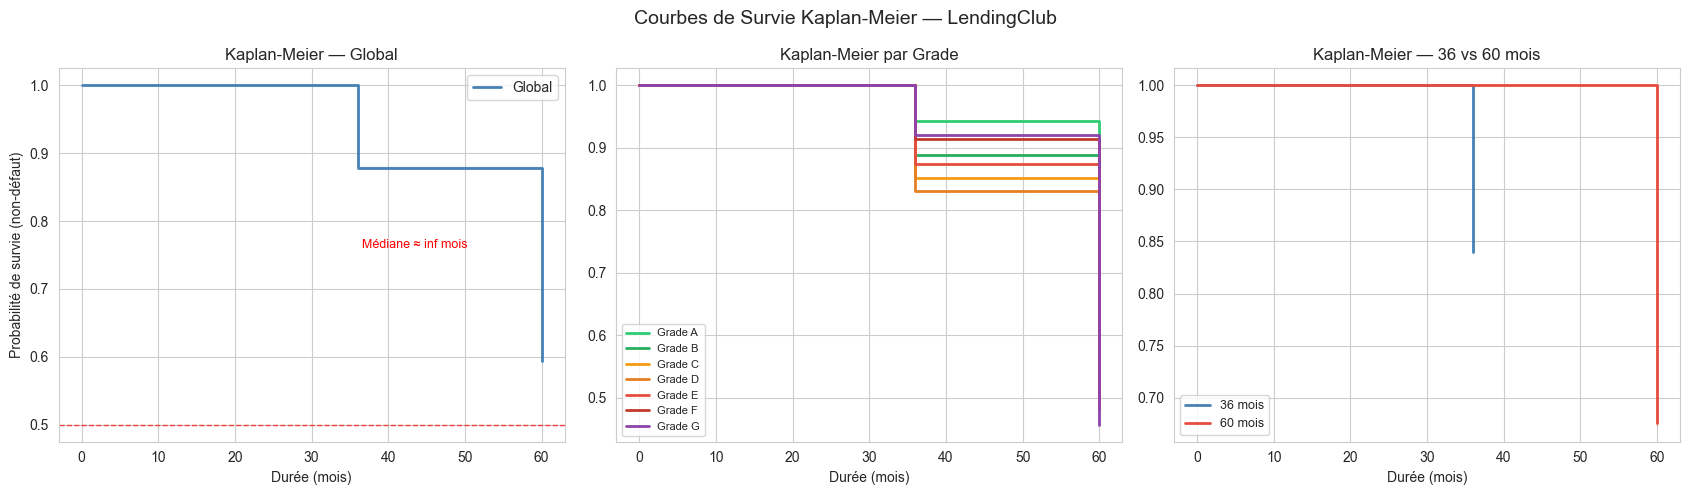

In [5]:
# KM global
kmf = KaplanMeierFitter()
kmf.fit(df_surv['duration_months'], event_observed=df_surv['event'], label='Global')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Plot 1 : Global ──────────────────────────────────────────────────
ax = axes[0]
kmf.plot_survival_function(ax=ax, ci_show=True, color='steelblue', lw=2)
ax.set_title('Kaplan-Meier — Global', fontsize=12)
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Probabilité de survie (non-défaut)')
med = kmf.median_survival_time_
ax.axhline(0.5, ls='--', color='red', lw=1, alpha=0.7)
ax.text(0.6, 0.52, f'Médiane ≈ {med:.0f} mois', transform=ax.transAxes, color='red', fontsize=9)

# ── Plot 2 : Par grade ───────────────────────────────────────────────
ax = axes[1]
if 'grade' in df_surv.columns:
    colors_grade = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']
    grade_labels = {1:'A',2:'B',3:'C',4:'D',5:'E',6:'F',7:'G'}
    for grade_val, color in zip(sorted(df_surv['grade'].dropna().unique()), colors_grade):
        mask = df_surv['grade'] == grade_val
        if mask.sum() > 100:
            kmf_g = KaplanMeierFitter()
            kmf_g.fit(df_surv.loc[mask,'duration_months'],
                      event_observed=df_surv.loc[mask,'event'],
                      #label=f"Grade {grade_labels.get(int(grade_val), grade_val)}")
                      label=f"Grade {grade_val}")
            kmf_g.plot_survival_function(ax=ax, ci_show=False, color=color, lw=2)
    ax.set_title('Kaplan-Meier par Grade', fontsize=12)
    ax.set_xlabel('Durée (mois)')
    ax.set_ylabel('')
    ax.legend(fontsize=8, loc='lower left')

# ── Plot 3 : Par durée du prêt (term) ───────────────────────────────
ax = axes[2]
if 'term' in df_surv.columns:
    for term_val, color, label in [(36,'steelblue','36 mois'),(60,'#e74c3c','60 mois')]:
        mask = df_surv['term'] == term_val
        if mask.sum() > 100:
            kmf_t = KaplanMeierFitter()
            kmf_t.fit(df_surv.loc[mask,'duration_months'],
                      event_observed=df_surv.loc[mask,'event'],
                      label=label)
            kmf_t.plot_survival_function(ax=ax, ci_show=True, color=color, lw=2)
    ax.set_title('Kaplan-Meier — 36 vs 60 mois', fontsize=12)
    ax.set_xlabel('Durée (mois)')
    ax.set_ylabel('')
    ax.legend(fontsize=9)

plt.suptitle('Courbes de Survie Kaplan-Meier — LendingClub', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROCESSED}/14_kaplan_meier.png', dpi=130)
plt.show()

In [6]:
# Test log-rank entre grades A et G (H0 : mêmes courbes)
if 'grade' in df_surv.columns:
    for g1, g2 in [(1, 7), (1, 4), (4, 7)]:
        mask1 = df_surv['grade'] == g1
        mask2 = df_surv['grade'] == g2
        if mask1.sum() > 50 and mask2.sum() > 50:
            result = logrank_test(
                df_surv.loc[mask1, 'duration_months'], df_surv.loc[mask2, 'duration_months'],
                event_observed_A=df_surv.loc[mask1, 'event'],
                event_observed_B=df_surv.loc[mask2, 'event']
            )
            grade_labels = {1:'A',4:'D',7:'G'}
            print(f'  Log-rank Grade {grade_labels[g1]} vs {grade_labels[g2]} : '
                  f'p-value = {result.p_value:.2e} '
                  f'({"✅ significatif" if result.p_value < 0.05 else "❌ non significatif"})')

## 3. Cox Proportional Hazard ★

**Modèle :**  h(t|x) = h₀(t) · exp(β₁x₁ + β₂x₂ + ...)

- **h₀(t)** : risque de base (baseline hazard) — fonction du temps
- **exp(βᵢ)** : Hazard Ratio — si > 1, la feature augmente le risque de défaut ; si < 1, elle le réduit
- **Hypothèse PH** : les hazard ratios sont constants dans le temps (à vérifier !)

In [7]:
# Préparation des features pour Cox PH
cox_features = [
    'loan_amnt', 'int_rate', 'grade', 'annual_inc', 'dti',
    'fico_range_low', 'revol_util', 'term', 'emp_length',
    'open_acc', 'total_acc', 'pub_rec'
]
cox_features = [f for f in cox_features if f in df_surv.columns]

df_cox = df_surv[cox_features + ['duration_months', 'event']].dropna()

# Normalisation (Cox PH sensible aux échelles)
scaler_cox = StandardScaler()
df_cox_scaled = df_cox.copy()
#df_cox_scaled[cox_features] = scaler_cox.fit_transform(df_cox[cox_features])

# Separate numeric and categorical columns
num_cols = df_cox[cox_features].select_dtypes(include=['int64','float64']).columns
cat_cols = df_cox[cox_features].select_dtypes(include=['object']).columns

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_cox[cox_features], columns=cat_cols, drop_first=True)

# Scale everything
scaler_cox = StandardScaler()
df_scaled_values = scaler_cox.fit_transform(df_encoded)

# Rebuild dataframe
df_cox_scaled = pd.DataFrame(df_scaled_values, columns=df_encoded.columns, index=df_cox.index)

# Add survival columns back
df_cox_scaled['duration_months'] = df_cox['duration_months']
df_cox_scaled['event'] = df_cox['event']

print(f'✅ Dataset Cox PH : {df_cox_scaled.shape}')
print(f'   Features utilisées : {cox_features}')

✅ Dataset Cox PH : (1345310, 19)
   Features utilisées : ['loan_amnt', 'int_rate', 'grade', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'term', 'emp_length', 'open_acc', 'total_acc', 'pub_rec']


In [8]:
# Entraînement du modèle Cox PH (lifelines)
print('⏳ Cox Proportional Hazard ...')
cph = CoxPHFitter(penalizer=0.1)  # pénalisation L2 légère
cph.fit(
    df_cox_scaled,
    duration_col  = 'duration_months',
    event_col     = 'event',
    show_progress = False
)

print(f'\n✅ Cox PH ajusté')
print(f'   C-index (train) : {cph.concordance_index_:.4f}')

# Résumé
summary = cph.summary[['coef', 'exp(coef)', 'p', 'coef lower 95%', 'coef upper 95%']].sort_values('coef', ascending=False)
print('\nHazard Ratios (exp(coef)) — trié par effet :')
print(summary.to_string(float_format='{:.4f}'.format))

⏳ Cox Proportional Hazard ...

✅ Cox PH ajusté
   C-index (train) : 0.7429

Hazard Ratios (exp(coef)) — trié par effet :
                  coef  exp(coef)      p  coef lower 95%  coef upper 95%
covariate                                                               
int_rate        0.1472     1.1586 0.0000          0.1433          0.1512
grade_D         0.0795     1.0827 0.0000          0.0761          0.0828
grade_C         0.0620     1.0640 0.0000          0.0585          0.0656
open_acc        0.0511     1.0524 0.0000          0.0476          0.0546
grade_E         0.0489     1.0502 0.0000          0.0458          0.0520
dti             0.0317     1.0323 0.0000          0.0304          0.0331
grade_F         0.0236     1.0239 0.0000          0.0209          0.0263
pub_rec         0.0202     1.0204 0.0000          0.0175          0.0229
grade_G         0.0121     1.0122 0.0000          0.0097          0.0145
revol_util     -0.0010     0.9990 0.5340         -0.0044          0.0023
gra

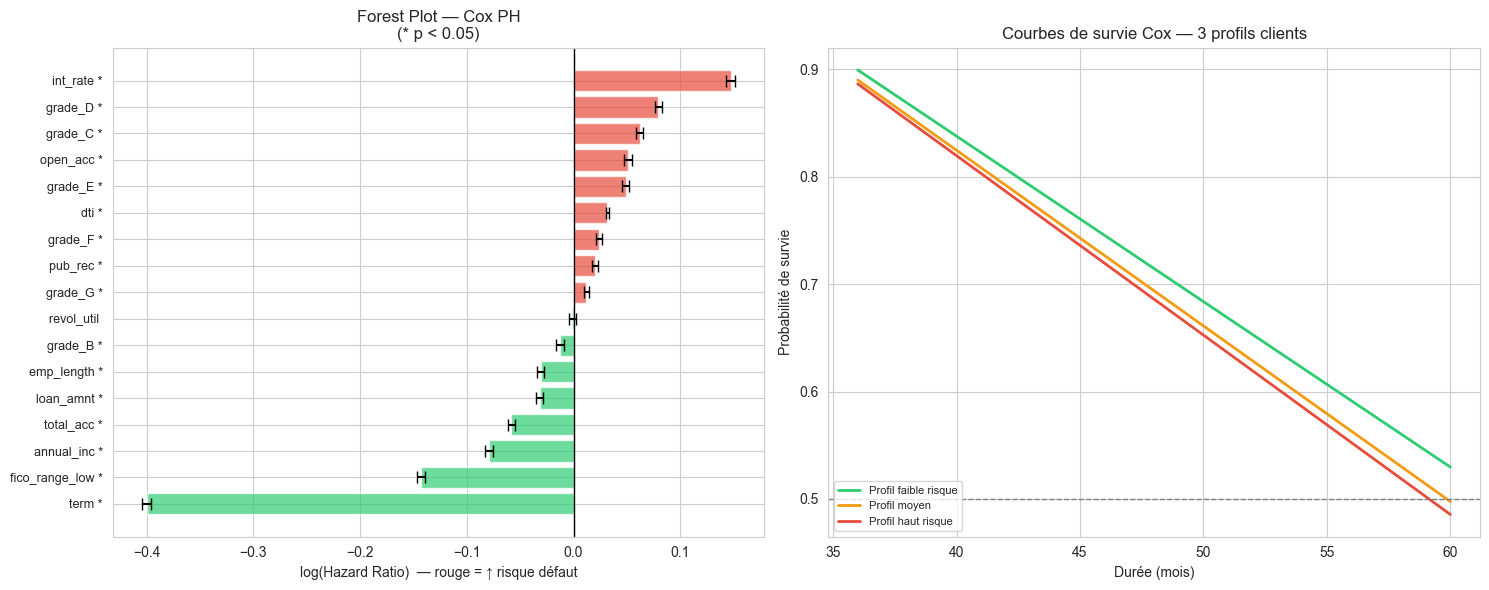

In [9]:
# Forest Plot des Hazard Ratios
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Forest Plot
ax = axes[0]
coefs = cph.summary['coef'].sort_values()
lower = cph.summary['coef lower 95%'].loc[coefs.index]
upper = cph.summary['coef upper 95%'].loc[coefs.index]
pvals = cph.summary['p'].loc[coefs.index]

y_pos = np.arange(len(coefs))
colors_hr = ['#e74c3c' if c > 0 else '#2ecc71' for c in coefs]
ax.barh(y_pos, coefs, xerr=[coefs - lower, upper - coefs],
        color=colors_hr, alpha=0.7, edgecolor='white', capsize=4)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{f} {"*" if p < 0.05 else ""}' for f, p in zip(coefs.index, pvals)], fontsize=9)
ax.set_xlabel('log(Hazard Ratio)  — rouge = ↑ risque défaut')
ax.set_title('Forest Plot — Cox PH\n(* p < 0.05)', fontsize=12)

# Courbe de survie Cox pour 3 profils
ax = axes[1]
"""
profiles = {
    'Profil faible risque (Grade A, DTI bas)' : {f: 0 for f in cox_features},
    'Profil moyen (Grade C, DTI moyen)'       : {f: 0 for f in cox_features},
    'Profil haut risque (Grade E, DTI élevé)' : {f: 0 for f in cox_features},
}
"""
# Use the SAME columns as training data
model_features = df_cox_scaled.drop(columns=['duration_months','event']).columns

profiles = {
    'Profil faible risque': pd.Series(0, index=model_features),
    'Profil moyen': pd.Series(0, index=model_features),
    'Profil haut risque': pd.Series(0, index=model_features),
}
"""
# Ajuster grade et dti pour chaque profil
if 'grade' in cox_features:
    profiles['Profil faible risque (Grade A, DTI bas)']['grade']  = -1.5  # standardisé
    profiles['Profil moyen (Grade C, DTI moyen)']['grade']        = 0.0
    profiles['Profil haut risque (Grade E, DTI élevé)']['grade']  = 1.5
    """
if 'dti' in model_features:
    profiles['Profil faible risque']['dti'] = -1.0
    profiles['Profil haut risque']['dti'] = 1.5

# Handle encoded grade properly
if 'grade_C' in model_features:
    profiles['Profil moyen']['grade_C'] = 1

if 'grade_E' in model_features:
    profiles['Profil haut risque']['grade_E'] = 1
"""
if 'dti' in cox_features:
    profiles['Profil faible risque (Grade A, DTI bas)']['dti']    = -1.0
    profiles['Profil haut risque (Grade E, DTI élevé)']['dti']    = 1.5
"""
colors_p = ['#2ecc71', '#f39c12', '#e74c3c']
for (name, profile), color in zip(profiles.items(), colors_p):
    df_profile = pd.DataFrame([profile])
    survival   = cph.predict_survival_function(df_profile)
    ax.plot(survival.index, survival.iloc[:, 0], label=name, color=color, lw=2)

ax.set_title('Courbes de survie Cox — 3 profils clients', fontsize=12)
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Probabilité de survie')
ax.legend(fontsize=8, loc='lower left')
ax.axhline(0.5, ls='--', color='gray', lw=1)

plt.tight_layout()
plt.savefig(f'{PROCESSED}/15_cox_ph.png', dpi=130)
plt.show()

In [10]:
# Vérification hypothèse Proportional Hazards (test de Schoenfeld)
print('Vérification hypothèse PH — test de Schoenfeld :')

try:
    df_sample = df_cox_scaled.sample(5000, random_state=42)

    cph_sample = CoxPHFitter()
    cph_sample.fit(df_sample, duration_col='duration_months', event_col='event')
    
    cph_sample.check_assumptions(df_sample, p_value_threshold=0.05, show_plots=False)
    #cph.check_assumptions(df_cox_scaled, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f'  ℹ️  {e}')
    print('  → Si p < 0.05 pour une feature : hypothèse PH violée → utiliser le RSF à la place')

Vérification hypothèse PH — test de Schoenfeld :
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'loan_amnt' failed the non-proportional test: p-value is 0.0355.

   Advice 1: the functional form of the variable 'loan_amnt' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'loan_amnt' using pd.cut, and then specify it in
`strata=['loan_amnt', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'int_rate' failed the non-proportional test: p-value is 0.0478.

   Advice 1: the functional form of the variable 'int_rate' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functi

## 4. Random Survival Forest ★★ (hors cours)

**Avantages par rapport à Cox PH :**
- Ne suppose **pas** l'hypothèse PH (les hazard ratios peuvent varier dans le temps)
- Capture les **interactions non-linéaires** entre features
- Combine la puissance des **Random Forests** avec la **censure** de la survie

**Métrique : C-index** (Concordance Index)  
= probabilité que, pour deux patients, celui avec le score de risque le plus élevé fasse défaut en premier.  
Analogue à l'AUC-ROC : 0.5 = aléatoire, 1.0 = parfait.

In [11]:
# Préparation pour scikit-survival (format structured array)
# Échantillonnage pour limiter le temps de calcul (RSF est coûteux)
MAX_SAMPLES = 100_000
if len(df_cox) > MAX_SAMPLES:
    df_rsf = df_cox.sample(MAX_SAMPLES, random_state=42)
    print(f'ℹ️  Échantillonnage : {MAX_SAMPLES:,} lignes (RSF coûteux sur 2M)')
else:
    df_rsf = df_cox.copy()

# Structured array requis par scikit-survival
y_surv = Surv.from_dataframe('event', 'duration_months', df_rsf)
X_rsf  = df_rsf[cox_features].values

# Train/test split
X_rsf_train, X_rsf_test, y_rsf_train, y_rsf_test = train_test_split(
    X_rsf, y_surv, test_size=0.2, random_state=42
)

print(f'✅ Dataset RSF : train={len(X_rsf_train):,}  test={len(X_rsf_test):,}')

ℹ️  Échantillonnage : 100,000 lignes (RSF coûteux sur 2M)
✅ Dataset RSF : train=80,000  test=20,000


In [12]:
"""print('⏳ Random Survival Forest (patience ☕) ...')
import time
t0 = time.time()

rsf = RandomSurvivalForest(
    n_estimators    = 200,
    min_samples_leaf= 15,
    max_features    = 'sqrt',
    n_jobs          = -1,
    random_state    = 42,
)
rsf.fit(X_rsf_train, y_rsf_train)

elapsed = time.time() - t0

# C-index
c_index_rsf = rsf.score(X_rsf_test, y_rsf_test)
print(f'✅ RSF entraîné en {elapsed:.0f}s')
print(f'   C-index (test) : {c_index_rsf:.4f}')"""

# ─────────────────────────────────────────────────────────────
# RANDOM SURVIVAL FOREST (RSF)
# ─────────────────────────────────────────────────────────────

print('⏳ Random Survival Forest (patience ☕) ...')

import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

t0 = time.time()

# ── 1. Features ───────────────────────────────────────────────
cox_features = [
    'loan_amnt', 'int_rate', 'grade', 'annual_inc', 'dti',
    'fico_range_low', 'revol_util', 'term', 'emp_length',
    'open_acc', 'total_acc', 'pub_rec'
]
df_surv_sample = df_surv.sample(100000, random_state=42)
cox_features = [f for f in cox_features if f in df_surv_sample.columns]

X_rsf = df_surv_sample[cox_features].copy()

# ── 2. Clean emp_length (important) ───────────────────────────
if 'emp_length' in X_rsf.columns:
    X_rsf['emp_length'] = X_rsf['emp_length'].astype(str).str.extract('(\d+)')
    X_rsf['emp_length'] = X_rsf['emp_length'].astype(float)

# ── 3. One-hot encoding ───────────────────────────────────────
X_rsf = pd.get_dummies(X_rsf, drop_first=True)

# ── 4. Target (Survival format) ───────────────────────────────
y_rsf = Surv.from_dataframe(
    event='event',
    time='duration_months',
    data=df_surv_sample
)

# ── 5. Train / Test split ─────────────────────────────────────
X_rsf_train, X_rsf_test, y_rsf_train, y_rsf_test = train_test_split(
    X_rsf, y_rsf,
    test_size=0.2,
    random_state=42
)

# ── 6. Model RSF ──────────────────────────────────────────────
rsf = RandomSurvivalForest(
    n_estimators=100,        # réduit pour vitesse
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

# ── 7. Training ───────────────────────────────────────────────
rsf.fit(X_rsf_train, y_rsf_train)

elapsed = time.time() - t0

# ── 8. Evaluation ─────────────────────────────────────────────
c_index_rsf = rsf.score(X_rsf_test, y_rsf_test)

print(f'✅ RSF entraîné en {elapsed:.0f}s')
print(f'   C-index (test) : {c_index_rsf:.4f}')

# ── 9. Vérification rapide ────────────────────────────────────
print('\n📊 Vérification types:')
print(X_rsf_train.dtypes.value_counts())

⏳ Random Survival Forest (patience ☕) ...
✅ RSF entraîné en 78s
   C-index (test) : 0.6794

📊 Vérification types:
float64    11
bool        6
Name: count, dtype: int64


KeyError: "None of [Index([0, 4999, 9999, 14999, 19999], dtype='int64')] are in the [columns]"

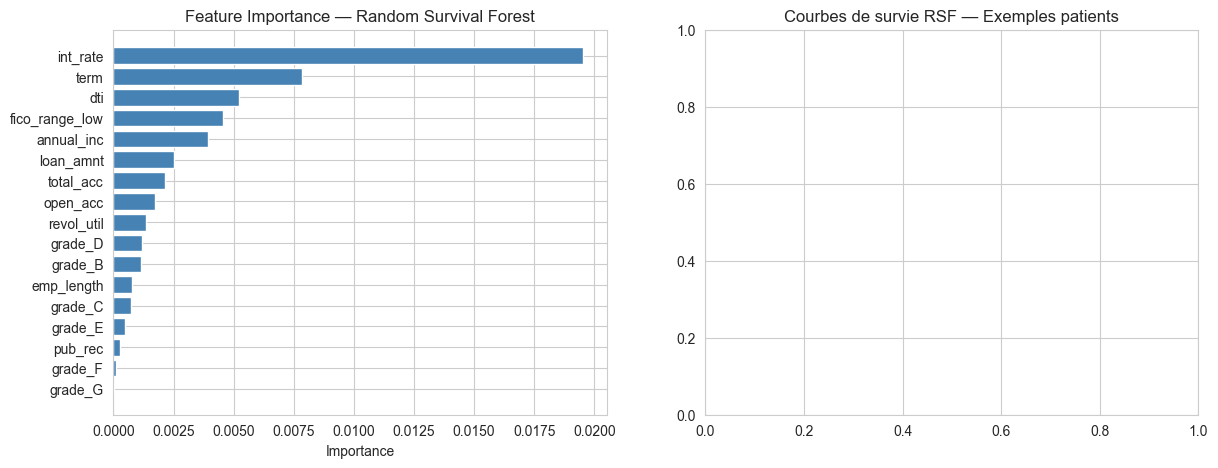

In [15]:
import numpy as np
if not hasattr(rsf, "estimators_") or len(rsf.estimators_) == 0:
    print("⚠️ RSF not fitted → refitting...")
    rsf.fit(X_rsf_train, y_rsf_train)
# Nombre de features après encoding
feature_names = X_rsf_train.columns

# Approximation rapide : variance des prédictions quand on shuffle chaque feature
importances = []

X_sample = X_rsf_test.sample(2000, random_state=42)
baseline = rsf.predict(X_sample)

for col in feature_names:
    X_tmp = X_sample.copy()
    X_tmp[col] = np.random.permutation(X_tmp[col].values)
    pred = rsf.predict(X_tmp)
    importances.append(np.mean((baseline - pred)**2))

feat_imp_rsf = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
# Feature Importance RSF
"""feat_imp_rsf = pd.DataFrame({
    'feature'   : cox_features,
    'importance': rsf.feature_importances_
}).sort_values('importance', ascending=False)"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
ax1.barh(feat_imp_rsf['feature'][::-1], feat_imp_rsf['importance'][::-1],
         color='steelblue', edgecolor='white')
ax1.set_title('Feature Importance — Random Survival Forest', fontsize=12)
ax1.set_xlabel('Importance')

# Courbes de survie RSF pour différents individus du test
ax2.set_title('Courbes de survie RSF — Exemples patients', fontsize=12)
# Sélectionner des individus représentatifs
sample_idx = np.linspace(0, len(X_rsf_test)-1, 5, dtype=int)
#times = rsf.event_times_
surv_fns = rsf.predict_survival_function(X_rsf_test[sample_idx])
colors_rsf = ['#2ecc71','#27ae60','#f39c12','#e74c3c','#8e44ad']
for i, (fn, color) in enumerate(zip(surv_fns, colors_rsf)):
    event_i = y_rsf_test[sample_idx[i]][0]  # True/False
    label = f'Client {i+1} ({"défaut" if event_i else "remboursé"})'
    ax2.step(fn.x, fn(fn.x), where='post', color=color, lw=2, label=label)
ax2.set_xlabel('Durée (mois)')
ax2.set_ylabel('Probabilité de survie')
ax2.legend(fontsize=8)
ax2.axhline(0.5, ls='--', color='gray', lw=1)

plt.tight_layout()
plt.savefig(f'{PROCESSED}/16_rsf_results.png', dpi=130)
plt.show()

## 5. Comparaison C-index — Cox PH vs RSF

   COMPARAISON C-INDEX — MODÈLES DE SURVIE
  Cox PH (scikit-survival)  : 0.7620
  Cox PH (lifelines-train)  : 0.7429  (sur train set)
  Random Survival Forest ★  : 0.6794

  🏆 Meilleur modèle de survie : Cox PH


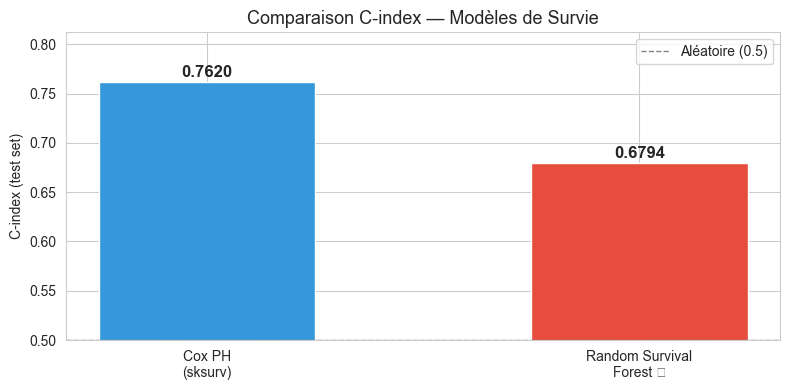

In [16]:
# C-index comparison — Cox PH (sksurv) vs RSF
# FIX : X_rsf_train / X_rsf_test are DataFrames after get_dummies in cell 17
#       → pas besoin de reconstruire avec df_rsf (qui n'existe plus)
#       → scaler renommé scaler_cox_sk pour éviter conflit avec scaler_cox de lifelines

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.preprocessing import StandardScaler

scaler_cox_sk  = StandardScaler()
X_rsf_train_sc = scaler_cox_sk.fit_transform(X_rsf_train)   # DataFrame → array
X_rsf_test_sc  = scaler_cox_sk.transform(X_rsf_test)

cox_sk = CoxPHSurvivalAnalysis(alpha=0.1)
cox_sk.fit(X_rsf_train_sc, y_rsf_train)
c_index_cox = cox_sk.score(X_rsf_test_sc, y_rsf_test)

# Tableau comparatif
print('='*52)
print('   COMPARAISON C-INDEX — MODÈLES DE SURVIE')
print('='*52)
print(f'  Cox PH (scikit-survival)  : {c_index_cox:.4f}')
# lifelines cph concordance_index_ est calculé sur train → préciser
if hasattr(cph, 'concordance_index_'):
    print(f'  Cox PH (lifelines-train)  : {cph.concordance_index_:.4f}  (sur train set)')
print(f'  Random Survival Forest ★  : {c_index_rsf:.4f}')
print('='*52)
best_surv = 'RSF' if c_index_rsf > c_index_cox else 'Cox PH'
print(f'\n  🏆 Meilleur modèle de survie : {best_surv}')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
models_surv = ['Cox PH\n(sksurv)', 'Random Survival\nForest ★']
c_indices   = [c_index_cox, c_index_rsf]
colors_surv = ['#3498db', '#e74c3c']
bars = ax.bar(models_surv, c_indices, color=colors_surv, edgecolor='white', width=0.5)
ax.set_ylim(0.5, min(1.0, max(c_indices) + 0.05))
ax.axhline(0.5, ls='--', color='gray', lw=1, label='Aléatoire (0.5)')
for bar, val in zip(bars, c_indices):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Comparaison C-index — Modèles de Survie', fontsize=13)
ax.set_ylabel('C-index (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROCESSED}/17_cindex_comparison.png', dpi=130)
plt.show()


## 6. Prédiction pour un nouveau client

   PRÉDICTION RSF — NOUVEAU CLIENT
  Profil : Grade D, int_rate=14.5%, DTI=22.0%
  Score de risque RSF    : 0.4027
  P(défaut à 12 mois)    : 19.4%
  P(défaut à 24 mois)    : 19.4%
  P(défaut à 36 mois)    : 19.4%


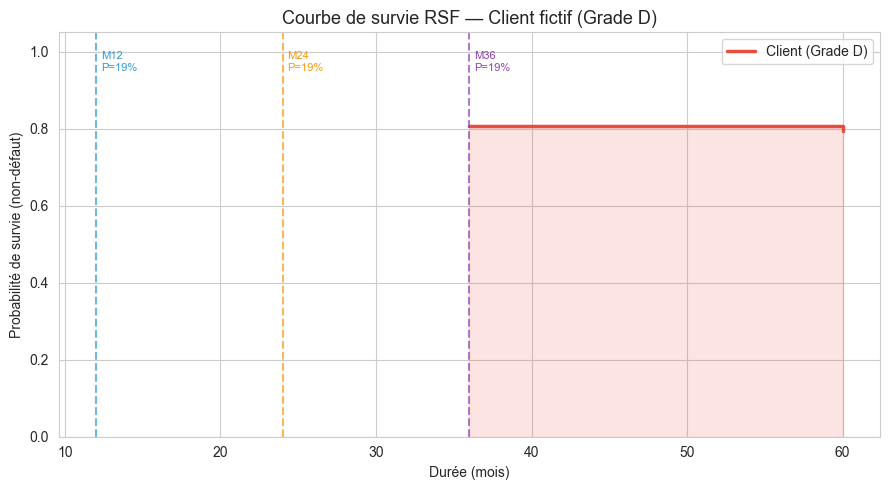

In [17]:
# Prédiction RSF pour un nouveau client
# FIX : X_rsf_train est un DataFrame post-get_dummies
#       → le nouveau client doit avoir exactement les mêmes colonnes

# Profil client fictif (features RAW — avant get_dummies)
nouveau_client_raw = {
    'loan_amnt'    : 15000,
    'int_rate'     : 14.5,
    'grade'        : 4,
    'annual_inc'   : 55000,
    'dti'          : 22.0,
    'fico_range_low': 670,
    'revol_util'   : 68.0,
    'term'         : 36,
    'emp_length'   : 3.0,
    'open_acc'     : 8,
    'total_acc'    : 20,
    'pub_rec'      : 0,
}

# Créer un DataFrame avec les mêmes colonnes que X_rsf_train
# (après get_dummies, il peut y avoir des colonnes booléennes supplémentaires)
X_new_df = pd.DataFrame([nouveau_client_raw])

# Aligner les colonnes : ajouter les colonnes manquantes avec 0, supprimer les extras
for col in X_rsf_train.columns:
    if col not in X_new_df.columns:
        X_new_df[col] = 0
X_new_df = X_new_df[X_rsf_train.columns]   # même ordre exact

# Prédiction RSF
surv_fn_new = rsf.predict_survival_function(X_new_df)[0]
risk_score  = rsf.predict(X_new_df)[0]

# Probabilité de défaut à N mois
def prob_defaut_a(surv_fn, mois):
    times = surv_fn.x
    vals  = surv_fn(times)
    idx   = np.searchsorted(times, mois)
    return float(1 - vals[min(idx, len(vals)-1)])

print('=' * 55)
print('   PRÉDICTION RSF — NOUVEAU CLIENT')
print('=' * 55)
print(f'  Profil : Grade D, int_rate={nouveau_client_raw["int_rate"]}%, DTI={nouveau_client_raw["dti"]}%')
print(f'  Score de risque RSF    : {risk_score:.4f}')
print(f'  P(défaut à 12 mois)    : {prob_defaut_a(surv_fn_new, 12)*100:.1f}%')
print(f'  P(défaut à 24 mois)    : {prob_defaut_a(surv_fn_new, 24)*100:.1f}%')
print(f'  P(défaut à 36 mois)    : {prob_defaut_a(surv_fn_new, 36)*100:.1f}%')
print('=' * 55)

# Graphique courbe de survie
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(surv_fn_new.x, surv_fn_new(surv_fn_new.x), where='post',
        color='#e74c3c', lw=2.5, label='Client (Grade D)')
ax.fill_between(surv_fn_new.x, surv_fn_new(surv_fn_new.x),
                step='post', alpha=0.15, color='#e74c3c')
for mois, color in [(12,'#3498db'), (24,'#f39c12'), (36,'#8e44ad')]:
    p = prob_defaut_a(surv_fn_new, mois)
    ax.axvline(mois, ls='--', color=color, lw=1.5, alpha=0.7)
    ax.text(mois+0.3, 0.95, f'M{mois}\nP={p*100:.0f}%', color=color, fontsize=8)
ax.set_title('Courbe de survie RSF — Client fictif (Grade D)', fontsize=13)
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Probabilité de survie (non-défaut)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{PROCESSED}/18_prediction_nouveau_client.png', dpi=130)
plt.show()


In [18]:
# Sauvegarde des modèles de survie
import json as json_mod

joblib.dump(rsf,         f'{MODELS}/rsf_model.pkl')
joblib.dump(cox_sk,      f'{MODELS}/cox_ph_sksurv.pkl')
joblib.dump(scaler_cox_sk, f'{MODELS}/scaler_cox_sk.pkl')   # FIX: renamed

# Lifelines Cox — sauvegarde conditionnelle (peut être absent si cellule skippée)
try:
    joblib.dump(cph, f'{MODELS}/cox_ph_lifelines.pkl')
    print('✅ cox_ph_lifelines.pkl sauvegardé')
except NameError:
    print('ℹ️  cph (lifelines) non disponible — cellule Cox skippée')

# Résumé JSON
surv_results = {
    'cox_ph_c_index'  : round(float(c_index_cox), 4),
    'rsf_c_index'     : round(float(c_index_rsf), 4),
    'cox_features'    : list(X_rsf_train.columns),    # colonnes post-get_dummies
    'n_features_rsf'  : int(X_rsf_train.shape[1]),
}
with open(f'{MODELS}/survival_results.json', 'w') as fj:
    json_mod.dump(surv_results, fj, indent=2)

print('✅ rsf_model.pkl      sauvegardé')
print('✅ cox_ph_sksurv.pkl  sauvegardé')
print('✅ survival_results.json sauvegardé')
print('\n→ Prochain : 07_conformal.ipynb')


✅ cox_ph_lifelines.pkl sauvegardé
✅ rsf_model.pkl      sauvegardé
✅ cox_ph_sksurv.pkl  sauvegardé
✅ survival_results.json sauvegardé

→ Prochain : 07_conformal.ipynb
